[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanyepesp/ISIS-4825_202610_IMAGENES_Y_VISION/blob/main/Laboratorio_07/Taller/MISIS4825_Laboratorio07_Taller.ipynb)

# Laboratorio 07 - Taller: Fundamentos de Machine Learning y Redes Neuronales

## Introducción

En este taller exploraremos el uso de TensorFlow y Keras para el diseño y entrenamiento de redes neuronales perceptrón multicapa. Utilizaremos el conjunto de datos **Pizza or not pizza?** para construir un modelo capaz de clasificar imágenes de acuerdo a su clase.

## Contenido del Taller

1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

2. **Construcción de un Modelo de Red Neuronal Perceptrón Multicapa**  
   - Desarrolle un modelo de red neuronal perceptrón multicapa utilizando Keras.  
   - Discuta la elección de la arquitectura, detallando el número de capas, la cantidad de neuronas por capa y las funciones de activación empleadas.

3. **Definición de Funciones de Callbacks para Monitorear el Entrenamiento**  
   - Implemente callbacks en TensorFlow y Keras para monitorear el proceso de entrenamiento.  
   - Explique cómo estos callbacks pueden ayudar a identificar problemas como el sobreajuste o un entrenamiento insuficiente.  
   - Justifique la selección y configuración de cada callback.

4. **Entrenamiento y Exploración de Resultados**  
   - Detalle el proceso de entrenamiento, incluyendo la elección de la tasa de aprendizaje, el optimizador y la función de pérdida.  
   - Analice los resultados obtenidos utilizando métricas de desempeño como precisión, recall y F1-score.  
   - Compare los resultados y discuta posibles mejoras en el modelo.

## Datos

[Pizza or not pizza?](https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza)

In [3]:
# librerías
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json
import kagglehub
from PIL import Image

1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

In [4]:
path = kagglehub.dataset_download("carlosrunner/pizza-not-pizza")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pizza-not-pizza' dataset.
Path to dataset files: /kaggle/input/pizza-not-pizza


Antes de transformar los datos, exploramos los contenidos del dataset.

In [10]:
# path con las imagenes
base_path = os.path.join(path, 'pizza_not_pizza')

# iterar por cada subcarpeta
for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)

    # si es una carpeta, ver cuantos archivos tiene
    if os.path.isdir(category_path):
        num_files = len(os.listdir(category_path))
        print(f"Carpeta '{category}': {num_files} archivos")

Carpeta 'not_pizza': 983 archivos
Carpeta 'pizza': 983 archivos


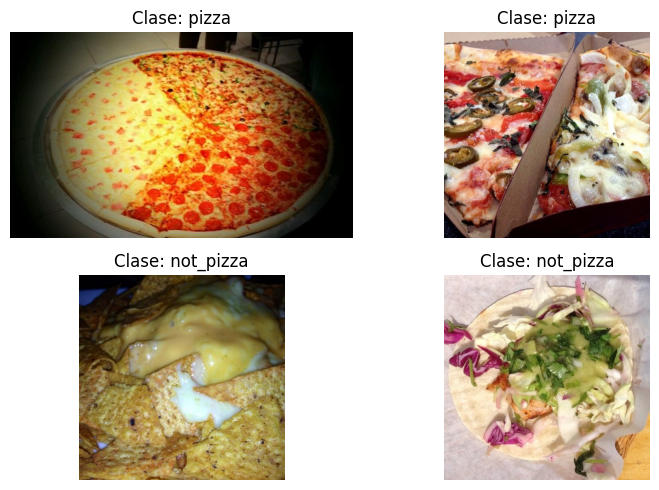

In [12]:
# visualizar dos imagenes de cada categoría
base_path = os.path.join(path, 'pizza_not_pizza')
categories = ['pizza', 'not_pizza']

plt.figure(figsize=(8, 5))

for i, category in enumerate(categories):
    category_path = os.path.join(base_path, category)
    images = os.listdir(category_path)[:2] # dos primeras imagenes de cada clase

    for j, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = Image.open(img_path)

        # crear dos subplots
        plt.subplot(2, 2, i * 2 + j + 1)
        plt.imshow(img)
        plt.title(f"Clase: {category}")
        plt.axis('off')

plt.tight_layout()
plt.show()